# **Quality Metrics Result Visualization**

In this notebook, the raw energy consumption data, with different configurations of inference batch sizes, is analyzed. The results are averaged over the five runs, along with the computation of the standard deviation for each tracked parameter.

In [1]:
# import required libraries
import matplotlib.font_manager as font_manager
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import glasbey
import os
import re

In [ ]:
# get working directory, necessary to gather the data to be analyzed
current_dir = os.getcwd()
print(f"Current Working Directory: {current_dir}")

## **Helper Functions**
Useful functions to properly format labels and visualize plots correctly.

In [3]:
def save_individual_plot(data, x_col, y_col, hue_col, xlabel, ylabel, filename, paletta, model_list, metrica, baseline):

    """
    Generates and saves a scatter plot with an overlaid Pareto front for
    quality metrics vs. GPU energy consumption.

    This function creates a scatter plot using Seaborn/Matplotlib to visualize the
    relationship between a specified quality metric (`y_col`) and GPU energy
    consumption (`x_col`), with different models distinguished via `hue_col`.
    The Pareto-efficient set is computed according to the metric
    and highlighted on the plot.

    Parameters:
    -----------
    data : pd.DataFrame
        The DataFrame containing the data to plot. Expected to include the columns
        specified by `x_col`, `y_col`, and `hue_col`

    x_col : str
        The name of the column in `data` to be used for the x-axis (GPU energy).

    y_col : str
        The name of the column in `data` to be used for the y-axis (quality metric).

    hue_col : str
        The name of the column in `data` to be used for differentiating plot points
        by color (model name).

    xlabel : str
        The label for the x-axis.

    ylabel : str
        The label for the y-axis (name of the metric)

    filename : str
        The path and name for saving the generated plot file.

    paletta : list
        Color palette to be used for the scatterplot

    model_list : list
        Ordered list of model names to plot. Used to index colors from the
        constructed palette and to iterate over models for markers.

    metrica : str
        Name used to look up the base metric column

    baseline : str
        The baseline name used for the plot title (appended to `ylabel`).

    Returns:
    --------
    None
        The function does not return a value but saves the generated plot to the
        specified file path.
    """

    figure, axes = plt.subplots(figsize=(10, 5))
    sns.scatterplot(
        data=data,
        x=x_col,
        y=y_col,
        hue=hue_col,
        style=hue_col,
        s=0,
        ax=axes,
        palette=paletta
    )

    newpalette = [dictcolors[key] for key in models if key in dictcolors]
    newpalette[11] = newpalette[10]; newpalette[9] = newpalette[8]; newpalette[7] = newpalette[8]

    import warnings
    warnings.filterwarnings("ignore", category=UserWarning)

    if ylabel=="FAD (Laion)":
        globales = data[[f"gpu_energy", f"{metrics[metrica][0]}_laion"]].to_numpy()
        # sort by x (energy consumption) ascending, then by y ({metrics[metr][0]}) ascending
        sorted_globales = globales[np.lexsort((globales[:, 1], globales[:, 0]))]
        globales_paretos = [sorted_globales[0]]
        for punti in sorted_globales[1:]:
            if punti[1] <= globales_paretos[-1][1]:  # lower y is better
                globales_paretos.append(punti)
    elif ylabel=="FAD (Encodec)":
        globales = data[[f"gpu_energy", f"{metrics[metrica][0]}_encodec"]].to_numpy()
        # sort by x (energy consumption) ascending, then by y ({metrics[metr][0]}) ascending
        sorted_globales = globales[np.lexsort((globales[:, 1], globales[:, 0]))]
        globales_paretos = [sorted_globales[0]]
        for punti in sorted_globales[1:]:
            if punti[1] <= globales_paretos[-1][1]:  # lower y is better
                globales_paretos.append(punti)
    elif metrica=="Audiobox":
        globales = data[[f"gpu_energy", f"{y_col}"]].to_numpy()
        # sort by x (energy consumption) ascending, then by y ({metrics[metr][0]}) ascending
        sorted_globales = globales[np.lexsort((globales[:, 1], globales[:, 0]))]
        globales_paretos = [sorted_globales[0]]
        for punti in sorted_globales[1:]:
            if punti[1] >= globales_paretos[-1][1]:  # lower y is better
                globales_paretos.append(punti)
    else:
        globales = data[[f"gpu_energy", f"{metrics[metrica][0]}"]].to_numpy()
        # sort by x (energy consumption) ascending, then by y descending (higher is better for CLAPscore)
        sorted_globales = globales[np.lexsort((-globales[:, 1], globales[:, 0]))]
        globales_paretos = [sorted_globales[0]]
        for punti in sorted_globales[1:]:
            if punti[1] >= globales_paretos[-1][1]:  # higher y is better for CLAPscore
                globales_paretos.append(punti)

    globales_paretos = np.array(globales_paretos)

    axes.plot(
        globales_paretos[:, 0], globales_paretos[:, 1],
        linestyle='--', color='red', alpha=0.5, linewidth=1.5, label='Pareto Front'
    )
    markers = dict(zip(steps, seaborn_markers))

    suffix_re = re.compile(r'(Small|Medium|Large)$', re.IGNORECASE)

    for model_name in model_list:
        model_col = 'Model' if metrica == "Audiobox" else 'model'
        model_data = data[data[model_col] == model_name]

        if model_data.empty:
            m = suffix_re.search(model_name)
            if m:
                base = model_name[:m.start()]
                variant = m.group()
                if 'size' in data.columns:
                    size_col = 'size'
                elif 'Size' in data.columns:
                    size_col = 'Size'
                else:
                    size_col = None

                if size_col is not None:
                    model_data = data[
                        (data[model_col] == base) &
                        (data[size_col].astype(str).str.lower() == variant.lower())
                    ]

        if model_data.empty:
            continue

        color_idx = model_list.index(model_name)

        for index, row in model_data.iterrows():
            x_value = row["gpu_energy"]
            if ylabel == "FAD (Laion)":
                y_value = row[f'{metrics[metrica][0]}_laion']
            elif ylabel == "FAD (Encodec)":
                y_value = row[f'{metrics[metrica][0]}_encodec']
            elif metrica == "Audiobox":
                y_value = row[f'{y_col}']
            else:
                y_value = row[f'{metrics[metrica][0]}']

            if metrica == "Audiobox":
                if pd.notna(row.get('Steps')) and row['Steps'] not in ["Small", "Medium", "Large"]:
                    step = int(row['Steps'])
                    marker_to_use = markers.get(step)
                else:
                    if model_name.endswith("Small"):
                        marker_to_use = "1"
                    elif model_name.endswith("Medium"):
                        marker_to_use = "2"
                    else:
                        marker_to_use = "3"
            else:
                if pd.notna(row.get('steps')):
                    step = int(row['steps'])
                    marker_to_use = markers.get(step)
                else:
                    if model_name.endswith("Small"):
                        marker_to_use = "1"
                    elif model_name.endswith("Medium"):
                        marker_to_use = "2"
                    else:
                        marker_to_use = "3"

            if marker_to_use:
                axes.scatter(x_value, y_value, marker=marker_to_use, s=400,
                             color=newpalette[color_idx], linewidths=2)

                if [x_value, y_value] in globales_paretos.tolist():
                    if marker_to_use in ('1', '2', '3'):
                        axes.scatter(x_value, y_value, marker=marker_to_use, s=600, zorder=5,
                                     facecolors='red', linewidths=2)
                        axes.scatter(x_value, y_value, marker=marker_to_use, s=400, zorder=5,
                                     facecolors=newpalette[color_idx], linewidths=1)
                    else:
                        axes.scatter(x_value, y_value, marker=marker_to_use, s=600, zorder=5,
                                     facecolors=newpalette[color_idx], edgecolors='red',
                                     linewidths=2)

    axes.set_xlabel(xlabel, fontsize=26)
    axes.set_ylabel(ylabel, fontsize=26)
    ymin, ymax = axes.get_ylim()
    axes.set_ylim(ymin-0.01, ymax+0.01)
    if ylabel != "FAD (Encodec)":
        axes.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
    axes.tick_params(axis='x', labelsize=20)
    axes.tick_params(axis='y', labelsize=20)
    axes.set(xscale="log")
    axes.set_xticks(custom_positions)
    axes.set_xticklabels(custom_labels, fontsize=20, fontname='Times New Roman')
    axes.set_title(ylabel + f" - {baseline.capitalize()}", fontsize=28, pad=10)
    axes.legend([], [], frameon=False)
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

In [4]:
def getdata(metr, modelli, base):
    """
    Retrieves and merges quality metrics and emission data for multiple models
    and filters by a specific baseline.

    Parameters:
    -----------
    metr : str
        The name of the quality metric to retrieve data for ("FAD", "CLAP", or "Audiobox").

    modelli : list[str]
        A list of model names for which to retrieve and merge data.

    base : str
        The baseline name to filter the combined data by.

    Returns:
    --------
    pd.DataFrame
        A pandas DataFrame containing the merged quality metrics and emission
        data for all specified models, filtered to include only the rows
        corresponding to the specified baseline.
    """
    data = [[] for _ in modelli]

    for r, modello in enumerate(modelli):
        if not modello.startswith("Magnet") and not modello.startswith("MusicGen"):
            file_path = rf"{current_dir}\results\quality_metrics\{metr}\{modello}_{metrics[metr][0]}s.csv"
            en_path = rf"{current_dir}\results\quality_metrics\Emissions\{modello}\{modello}_emissions.csv"
            if metr == "Audiobox":
                file_path = rf"{current_dir}\results\quality_metrics\{metr}\{modello}\{modello}_{metr.lower()}.csv"
                en_path = rf"{current_dir}\results\quality_metrics\Emissions\{modello}\{modello}_emissions.csv"
        else:
            nondiff = re.sub(r"(MusicGen|Magnet)(Small|Medium|Large)", r"\1", modello)
            file_path = rf"{current_dir}\results\quality_metrics\{metr}\{modello}_{metrics[metr][0]}s.csv"
            en_path = rf"{current_dir}\results\quality_metrics\Emissions\{nondiff}\{modello}_emissions.csv"
            if metr == "Audiobox":
                nondiff = re.sub(r"(MusicGen|Magnet)(Small|Medium|Large)", r"\1", modello)
                file_path = rf"{current_dir}\results\quality_metrics\{metr}\{nondiff}\{modello}_{metr.lower()}.csv"
                en_path = rf"{current_dir}\results\quality_metrics\Emissions\{nondiff}\{modello}_emissions.csv"
        data[r] = pd.read_csv(file_path)
        energy = pd.read_csv(en_path)
        for col in ['emissions', 'gpu_energy']:
            if not modello.startswith("Magnet") and not modello.startswith("MusicGen"):
                if metr == "Audiobox":
                        data[r] = data[r].merge(energy[['steps', 'baseline', col]], how='left',
                            left_on=['Steps', 'Baseline'], right_on=['steps', 'baseline'])
                else:
                    data[r] = data[r].merge(energy[['steps', 'baseline', col]], on=['steps', 'baseline'], how='left')
            else:
                if metr == "Audiobox":
                    data[r] = data[r].merge(energy[['baseline', col]], how='left', left_on=['Baseline'], right_on=['baseline'])
                else:
                    data[r] = data[r].merge(energy[['baseline', col]], on=['baseline'], how='left')

    combinat = []
    for r, modello in enumerate(modelli):
        temp_data = data[r].copy()
        combinat.append(temp_data)
    combinat = pd.concat(combinat, ignore_index=True)
    if metr == "Audiobox":
        filtered_combinat = combinat[combinat["Baseline"] == base]
    else:
        filtered_combinat = combinat[combinat["baseline"] == base]

    return filtered_combinat

In [5]:
def make_legend():
    """
    Generates, plots, and saves a combined legend for model names and
    inference steps used in the plots.

    Returns:
    --------
    None
        The function does not return any value but saves the generated legend
        figure to a PDF file.
    """

    music_keys = [m for m in models if "musicgen" in m.lower() or m.lower().startswith("musicgen")]
    magnet_keys = [m for m in models if "magnet" in m.lower() or m.lower().startswith("magnet")]
    other_models = [m for m in models if m not in set(music_keys + magnet_keys)]

    def _color_for(k):
        return dictcolors.get(k, dictcolors.get(k.capitalize(), "black"))

    model_handles = [
        plt.Line2D([0], [0],
                marker=seaborn_markers[0], linestyle='None',
                markeredgecolor=_color_for(m),
                markerfacecolor=dictcolors.get(m, 'none'),
                markeredgewidth=1.2, markersize=12)
        for m in other_models
    ]

    music_color = dictcolors.get("MusicGenMedium", dictcolors.get("MusicGen", _color_for("MusicGenMedium")))
    magnet_color = dictcolors.get("MagnetSmall", dictcolors.get("Magnet", _color_for("MagnetSmall")))

    music_handle = plt.Line2D([0], [0],
                            marker=seaborn_markers[0], linestyle='None',
                            markeredgecolor=music_color, markerfacecolor=music_color,
                            markeredgewidth=1.2, markersize=12)
    magnet_handle = plt.Line2D([0], [0],
                            marker=seaborn_markers[0], linestyle='None',
                            markeredgecolor=magnet_color, markerfacecolor=magnet_color,
                            markeredgewidth=1.2, markersize=12)

    model_handles += [music_handle, magnet_handle]
    model_labels = [m[5:] if m.startswith("music") else m for m in other_models] + ["MusicGen", "Magnet"]

    marker_labels = ["  10 Inf. Steps", "  25 Inf. Steps", "  50 Inf. Steps",
                    "100 Inf. Steps", "150 Inf. Steps", "200 Inf. Steps", "Small", "Medium", "Large"]
    allmarkers = seaborn_markers + ["1", "2", "3"]
    marker_handles = [
        plt.Line2D([0], [0], marker=allmarkers[i], color='w', markeredgecolor="black",
                markerfacecolor='black', markersize=10)
        for i in range(len(allmarkers))
    ]


    fig2, axes2 = plt.subplots(figsize=(1, 1))
    axes2.axis("off")
    fig2.legend(model_handles, model_labels, bbox_to_anchor=(0.5, 0.8), columnspacing=4.62, ncol=9, fontsize=20, markerscale=2)
    fig2.legend(marker_handles, marker_labels, bbox_to_anchor=(0.5, 0.25), ncol=9 , fontsize=20, markerscale=2, columnspacing=3.56)
    fig2.savefig(rf"{current_dir}\figures\quality_metrics\legend.pdf", bbox_inches='tight')
    plt.show()

## **Figure plotting**
Using the previously defined functions, we now can now plot the analyze the data.

In [6]:
metrics = {"FAD": ["fad_score", "FAD"], "CLAP": ["clap_score", "CLAP Score"], "Audiobox": ["audiobox", "Audiobox"]}
fads = {"laion": ["fad_score_laion", "Laion"], "encodec": ["fad_score_encodec", "Encodec"]}
audioboxes = {"PC": "Production Complexity", "PQ": "Production Quality", "CE": "Content Enjoyment", "CU": "Content Usefulness"}

seaborn_markers = ["o", "s", "D", "^", "<", "X"]
steps = [10, 25, 50, 100, 150, 200]
custom_positions = [10 ** -1, 20 ** -1, 30 ** -1, 40 ** -1, 50 ** -1, 10 ** 0]
custom_labels = [r"10$^{-1}$", "", "", "", r"50$^{-1}$", r"10$^{0}$"]
models = ["musicAudioLDM", "musicAudioLDM2", "MusicLDM", "musicSAO", "musicTango", "ACEStep", "AudioX",
           "MusicGenSmall", "MusicGenMedium", "MusicGenLarge", "MagnetSmall", "MagnetMedium"]
modelsforpalette = ["musicAudioLDM", "a", "musicAudioLDM2", "b", "MusicLDM", "musicSAO", "c", "d", "e", "f", "g", "musicTango",
                    "AudioX", "ACEStep", "MusicGenSmall", "MusicGenMedium", "MusicGenLarge", "MagnetSmall", "MagnetMedium"]
colors = glasbey.create_palette(palette_size=len(modelsforpalette), colorblind_safe=True, cvd_severity=75)
dictcolors = dict(zip(modelsforpalette, colors))
newpalette = [dictcolors[key] for key in models if key in dictcolors]
newpalette[11] = newpalette[10]; newpalette[9] = newpalette[8]; newpalette[7] = newpalette[8]

sns.set_theme(style="whitegrid")
font_path = rf'{current_dir}\Times-Roman Regular.ttf'
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = prop.get_name()
plt.rcParams['legend.title_fontsize'] = 16

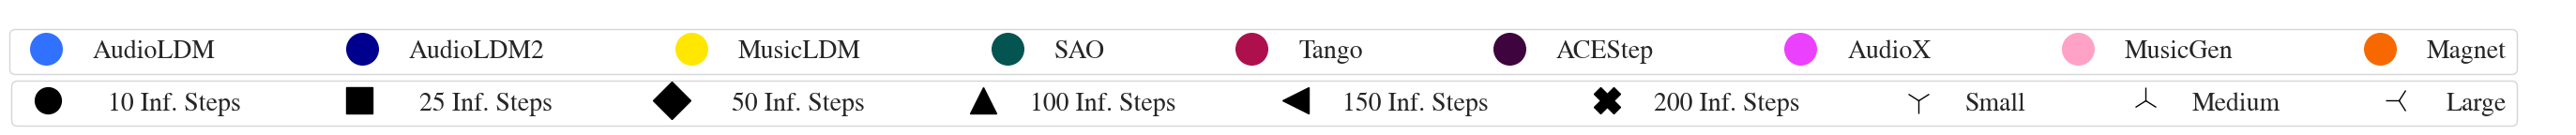

C:\Users\ricca\AppData\Local\Temp\ipykernel_6608\1904031176.py:59: UserWarning: The palette list has more values (12) than needed (9), which may not be intended.
  sns.scatterplot(


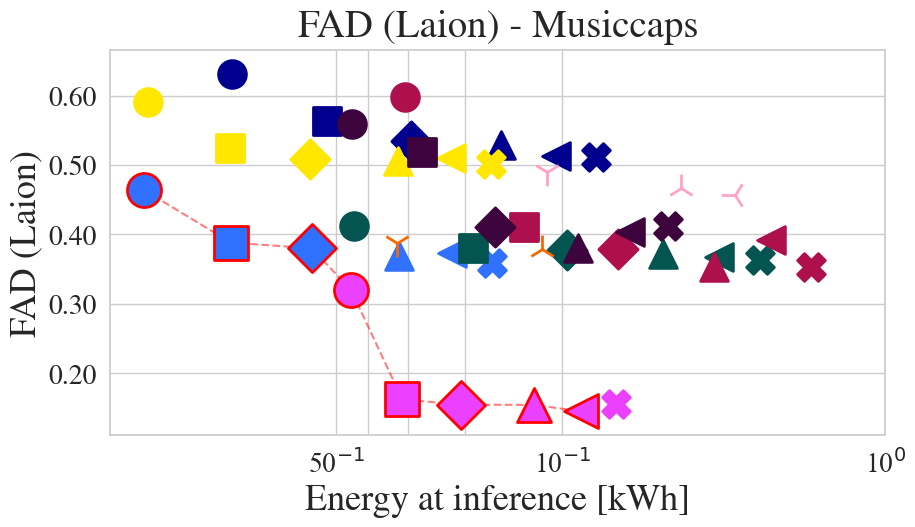

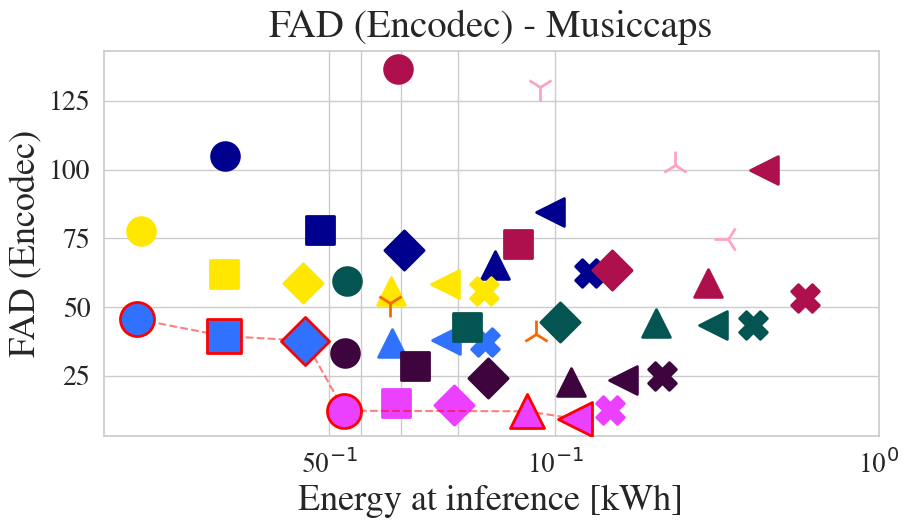

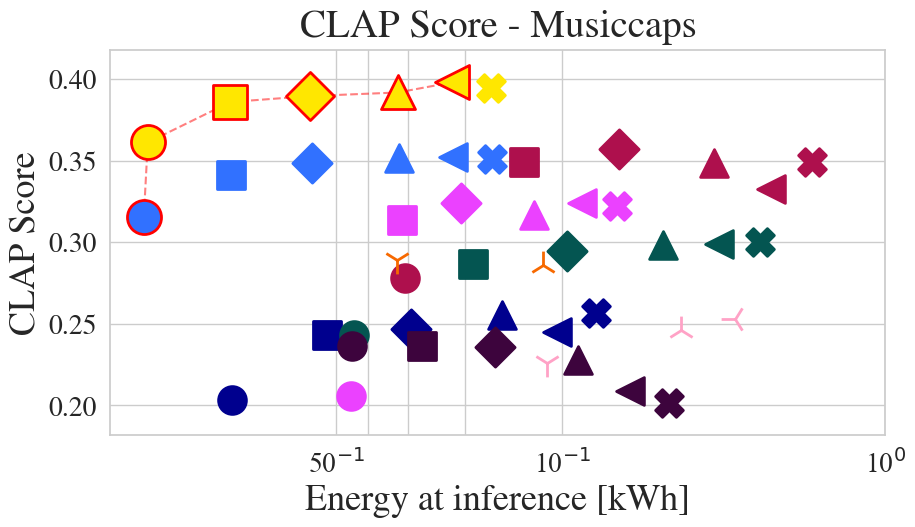

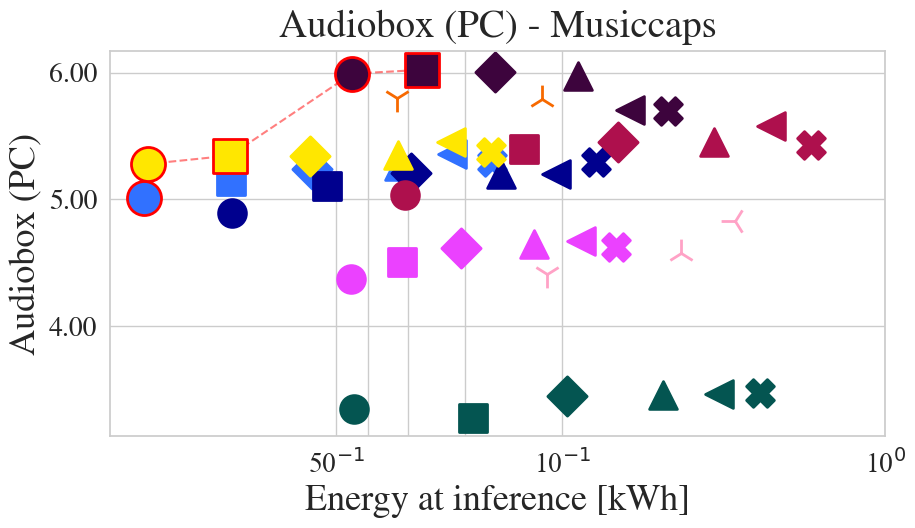

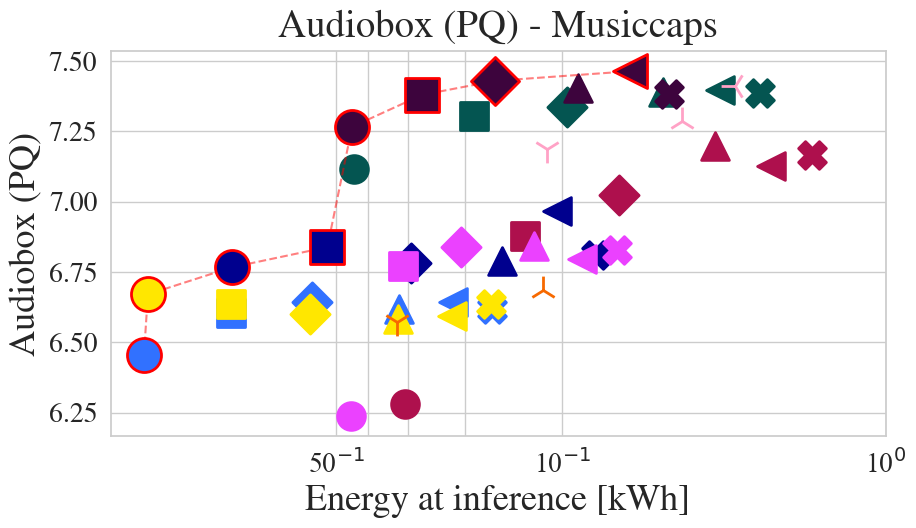

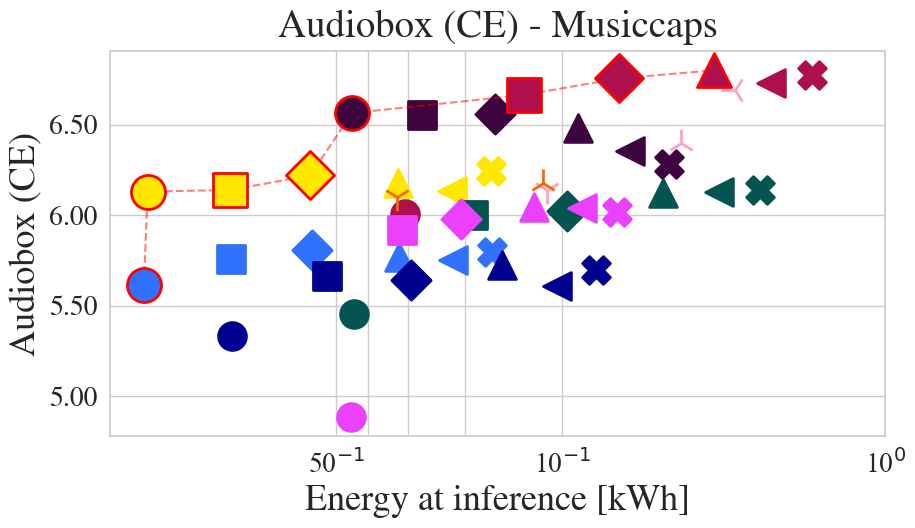

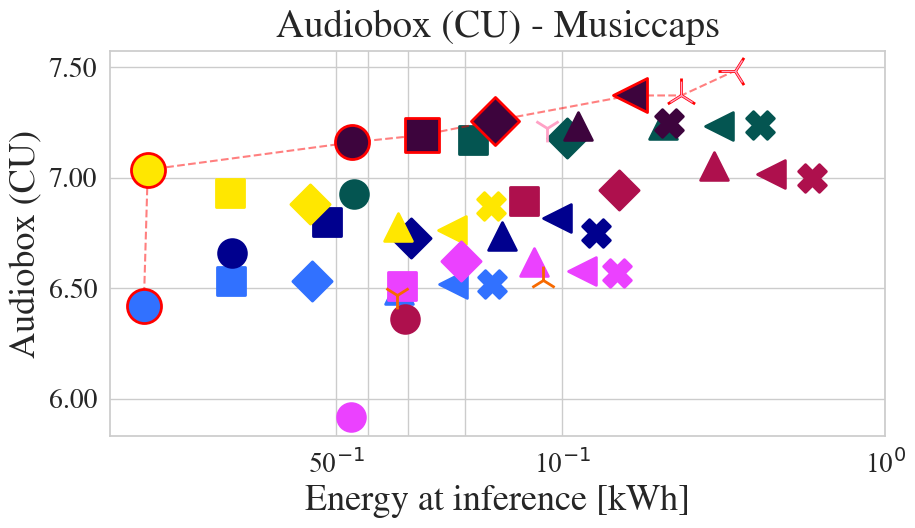

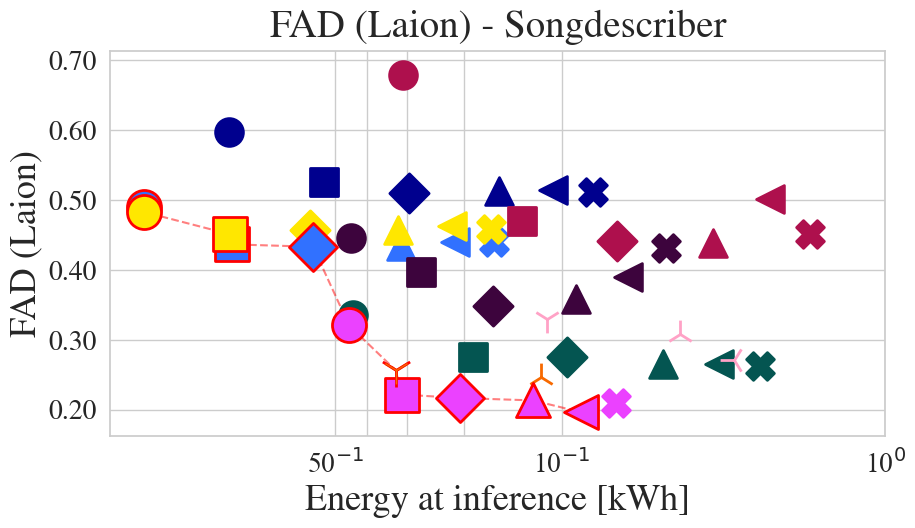

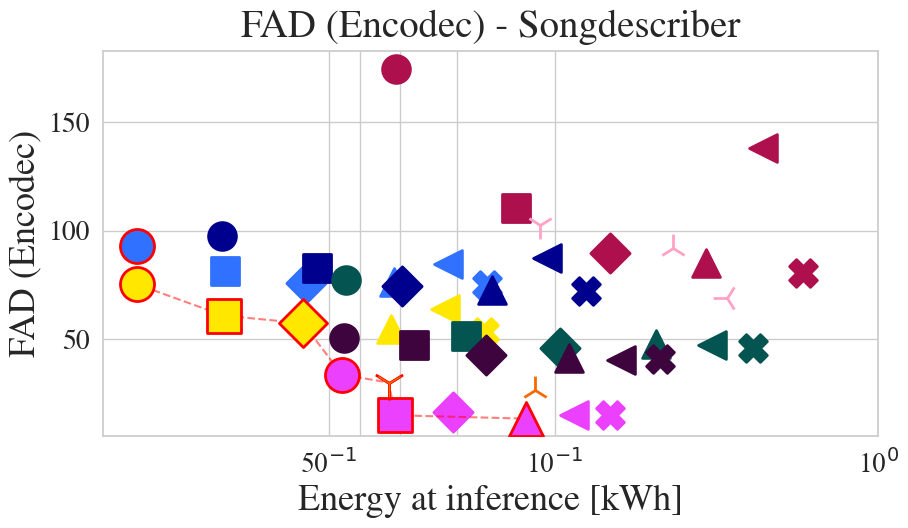

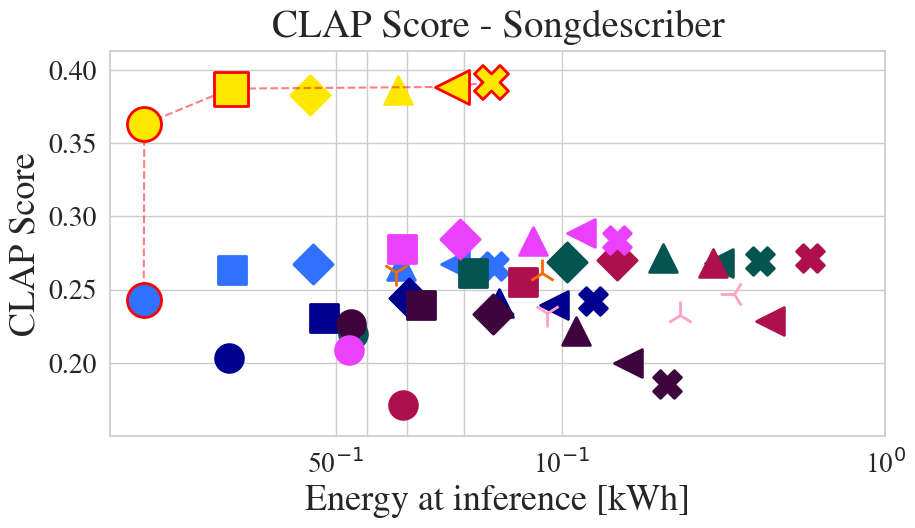

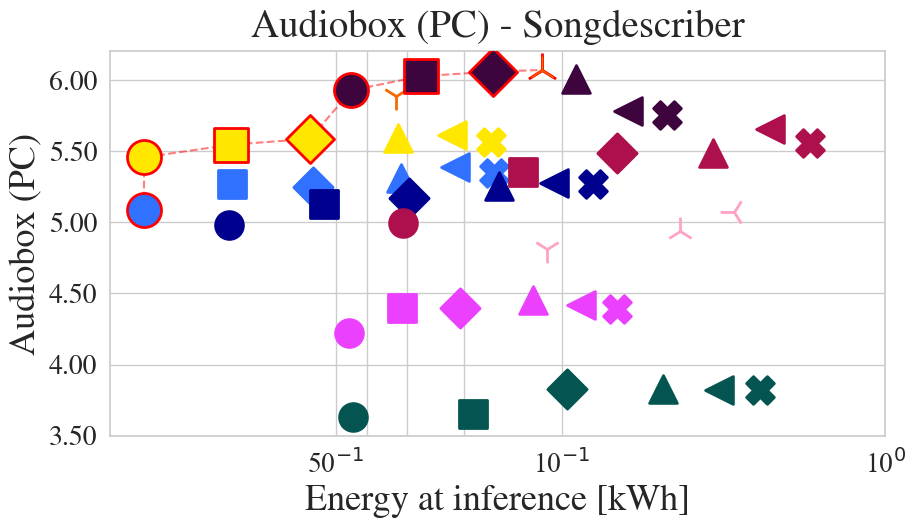

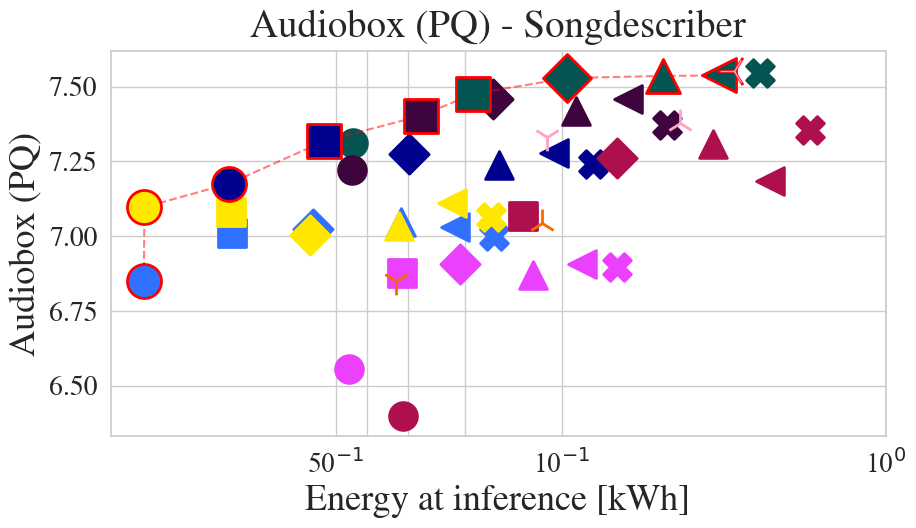

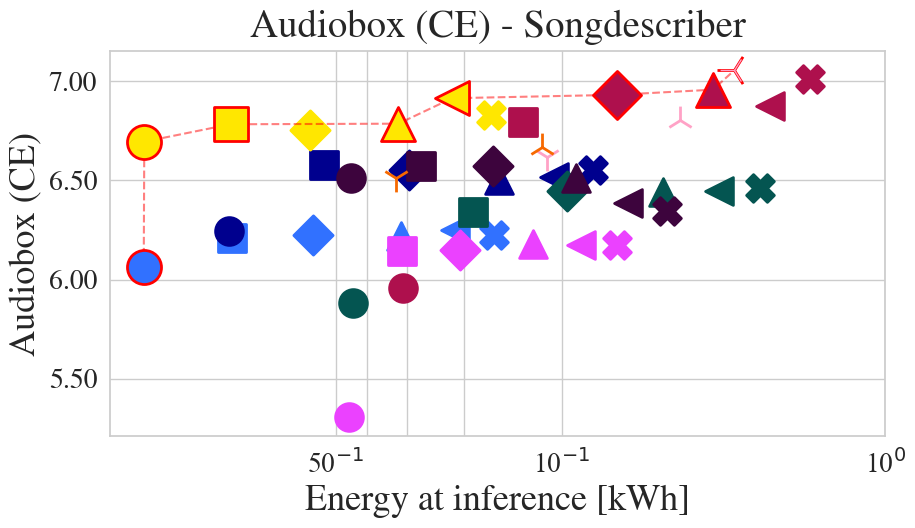

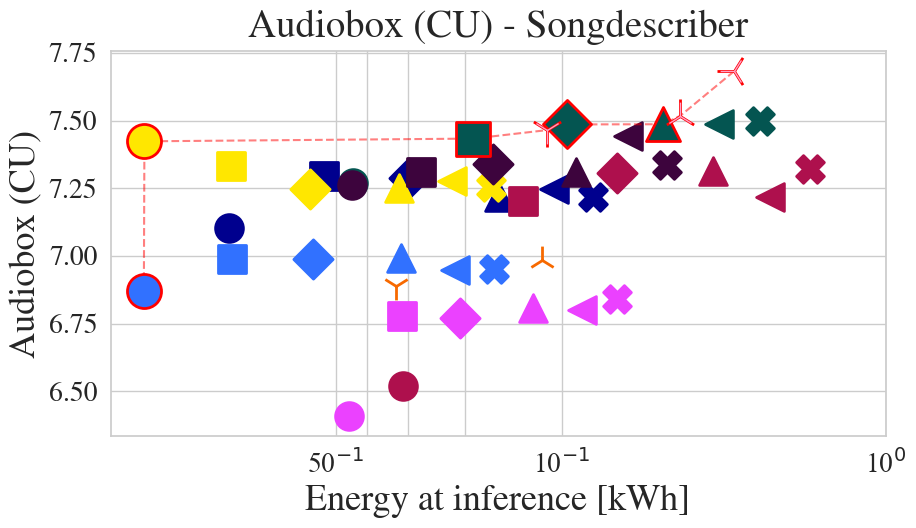

In [7]:
make_legend()

for baseline in ["musiccaps", "songdescriber"]:
    for metrica in ["FAD", "CLAP", "Audiobox"]:
        combined_data = getdata(metrica, models, baseline)
        if metrica=="FAD":
            for fad_key, fad_vals in fads.items():
                filename = rf"{current_dir}\figures\quality_metrics\{baseline}_{fad_vals[0]}.pdf"
                save_individual_plot(combined_data, "gpu_energy", f"{fad_vals[0]}", "model",
                                    "Energy at inference [kWh]", f"FAD ({fad_vals[1]})",
                                    filename, newpalette, models, metrica, baseline)
        elif metrica=="Audiobox":
            for ab_key, ab_val in audioboxes.items():
                filename = rf"{current_dir}\figures\quality_metrics\{baseline}_Audiobox{ab_key}.pdf"
                save_individual_plot(combined_data, "gpu_energy", f"Avg_{ab_key}", "Model",
                                    "Energy at inference [kWh]", f"{metrica} ({ab_key})",
                                    filename, newpalette, models, metrica, baseline)
        else:
            filename = rf"{current_dir}\figures\quality_metrics\{baseline}_{metrics[metrica][0]}.pdf"
            save_individual_plot(combined_data, "gpu_energy", f"{metrics[metrica][0]}", "model",
                                "Energy at inference [kWh]", f"{metrics[metrica][1]}",
                                filename, newpalette, models, metrica, baseline)